## Notes

**Model:** GRU

**Findings:**
- demand from mid March is decreasing significantly due to COVID-19 occurence


**Architecture:**
- Comparing 3 models

    1. **Model 1 (3 layers)**
       GRU -> Dropout -> Dense
    2. **Model 2 (5 layers)**
       GRU -> Droupout -> GRU -> Dropout -> Dense
    3. **Model 3 (7 layers)**
       GRU -> Dropout -> GRU -> Dropout -> GRU -> Dropout -> Dense

**Additional features from feature engineering:**
- lag features
- rolling mean
- cyclical time features (hour sin/cos, day of week sin/cos, month sin/cos)

**CV:**
4 fold
<table style="font-size:12px; width:50%">
  <tr><th>Fold</th><th>Train</th><th>Val</th></tr>
  <tr><td>CV1</td><td>2015-01 → 2015-12</td><td>2016-01 → 2016-12</td></tr>
  <tr><td>CV2</td><td>2015-01 → 2016-12</td><td>2017-01 → 2017-12</td></tr>
  <tr><td>CV3</td><td>2015-01 → 2017-12</td><td>2018-01 → 2018-12</td></tr>
  <tr><td>CV4</td><td>2015-01 → 2018-12</td><td>2019-01 → 2019-12</td></tr>
</table>

**Hyperparameter tuning:**
Keras tuner -> Bayesian optimization

**Forecast horizon:**
1hr & 6 hr

**Evaluation:**
MAE, RMSE, MAPE

## EDA

In [1]:
import pandas as pd

df = pd.read_csv("continuous dataset.csv")
df.tail()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
48043,2020-06-26 20:00:00,1128.5592,27.246545,0.020303,0.055511,9.289304,25.715295,0.019746,0.121552,1.990773,23.746545,0.018381,0.150879,2.444658,0,0,1
48044,2020-06-26 21:00:00,1112.7488,27.099573,0.020395,0.053848,9.837504,25.552698,0.019632,0.153870,2.094459,23.693323,0.018320,0.156311,2.515814,0,0,1
48045,2020-06-26 22:00:00,1081.5680,26.971155,0.020448,0.057251,10.262464,25.393030,0.019518,0.144531,2.396369,23.658655,0.018327,0.153259,2.800717,0,0,1
48046,2020-06-26 23:00:00,1041.6240,26.867487,0.020464,0.064178,10.326567,25.258112,0.019403,0.108063,2.720871,23.601862,0.018358,0.152771,3.138132,0,0,1
48047,2020-06-27 00:00:00,1013.5683,26.750330,0.020441,0.063965,10.198346,25.125330,0.019281,0.100189,2.785751,23.562830,0.018404,0.162598,3.286878,0,0,1


In [2]:
df[df["Holiday_ID"] == 4]

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
1031,2015-02-15 00:00:00,772.6091,25.824182,0.017999,0.144714,28.198588,25.269495,0.016397,0.087738,15.932520,22.175745,0.015584,0.158142,6.258242,4,1,0
1032,2015-02-15 01:00:00,777.7424,25.730432,0.017945,0.126404,28.775232,25.105432,0.016297,0.102936,15.946980,22.230432,0.015641,0.155701,6.650219,4,1,0
1033,2015-02-15 02:00:00,721.5908,25.686731,0.017900,0.099976,28.880590,25.030481,0.016214,0.106415,16.113815,22.288293,0.015657,0.157349,6.906899,4,1,0
1034,2015-02-15 03:00:00,726.2926,25.684167,0.017869,0.085052,28.132104,25.027917,0.016175,0.107605,16.176248,22.348230,0.015664,0.150269,7.204207,4,1,0
1035,2015-02-15 04:00:00,739.3178,25.730615,0.017763,0.069489,26.600725,25.035303,0.016176,0.108337,16.046259,22.402490,0.015672,0.136414,7.341165,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45066,2020-02-23 19:00:00,1156.1417,25.659906,0.014522,0.005501,24.654093,25.863031,0.014018,0.011929,14.034070,23.956781,0.013702,0.002204,6.844794,4,1,0
45067,2020-02-23 20:00:00,1164.5873,25.307001,0.014831,0.003329,23.524198,25.080438,0.014419,0.012959,13.277958,23.189813,0.014056,0.003761,6.641299,4,1,0
45068,2020-02-23 21:00:00,1124.5630,25.070886,0.015014,0.001614,22.384582,24.641199,0.014667,0.012634,12.324900,22.656824,0.014251,0.007761,6.410504,4,1,0
45069,2020-02-23 22:00:00,1096.2682,24.865686,0.015087,0.000589,21.888059,24.287561,0.014793,0.014534,11.937811,22.295374,0.014369,0.016602,6.374193,4,1,0


In [3]:
df.isna().sum()

datetime      0
nat_demand    0
T2M_toc       0
QV2M_toc      0
TQL_toc       0
W2M_toc       0
T2M_san       0
QV2M_san      0
TQL_san       0
W2M_san       0
T2M_dav       0
QV2M_dav      0
TQL_dav       0
W2M_dav       0
Holiday_ID    0
holiday       0
school        0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48048 entries, 0 to 48047
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    48048 non-null  object 
 1   nat_demand  48048 non-null  float64
 2   T2M_toc     48048 non-null  float64
 3   QV2M_toc    48048 non-null  float64
 4   TQL_toc     48048 non-null  float64
 5   W2M_toc     48048 non-null  float64
 6   T2M_san     48048 non-null  float64
 7   QV2M_san    48048 non-null  float64
 8   TQL_san     48048 non-null  float64
 9   W2M_san     48048 non-null  float64
 10  T2M_dav     48048 non-null  float64
 11  QV2M_dav    48048 non-null  float64
 12  TQL_dav     48048 non-null  float64
 13  W2M_dav     48048 non-null  float64
 14  Holiday_ID  48048 non-null  int64  
 15  holiday     48048 non-null  int64  
 16  school      48048 non-null  int64  
dtypes: float64(13), int64(3), object(1)
memory usage: 6.2+ MB


In [5]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [6]:
df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [7]:
#gap check
df_time = df.set_index('datetime')

full_range = pd.date_range(df_time.index.min(), df_time.index.max(), freq='h')
missing_hours = full_range.difference(df_time.index)
print(f"Missing timestamps: {len(missing_hours)}")

Missing timestamps: 0


In [8]:
df_time

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-26 20:00:00,1128.5592,27.246545,0.020303,0.055511,9.289304,25.715295,0.019746,0.121552,1.990773,23.746545,0.018381,0.150879,2.444658,0,0,1
2020-06-26 21:00:00,1112.7488,27.099573,0.020395,0.053848,9.837504,25.552698,0.019632,0.153870,2.094459,23.693323,0.018320,0.156311,2.515814,0,0,1
2020-06-26 22:00:00,1081.5680,26.971155,0.020448,0.057251,10.262464,25.393030,0.019518,0.144531,2.396369,23.658655,0.018327,0.153259,2.800717,0,0,1


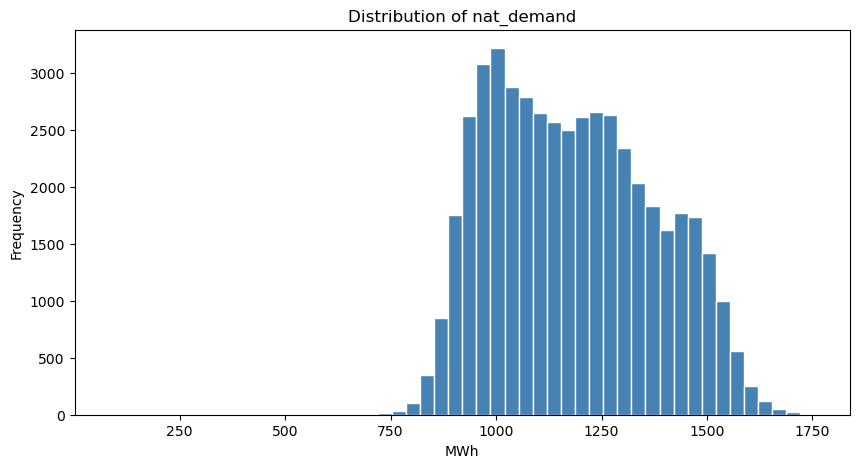

In [9]:
#histogram

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['nat_demand'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of nat_demand')
plt.xlabel('MWh')
plt.ylabel('Frequency')
plt.show()

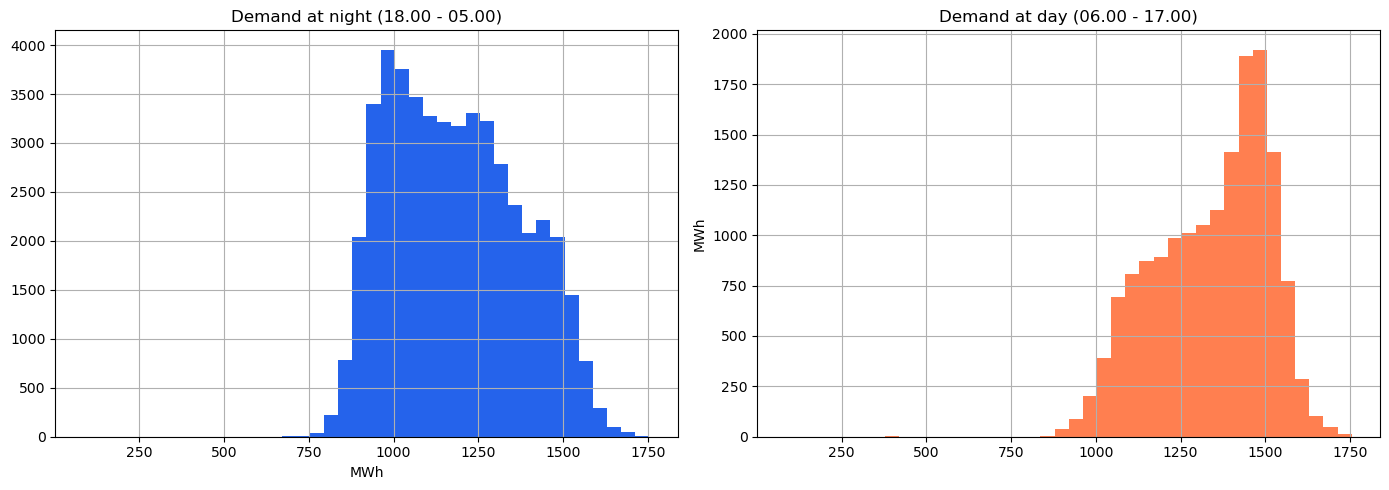

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_time[df_time.index.hour.isin(list(range(0,24)) + list(range(0,6)))]['nat_demand'].hist(bins=40, ax=axes[0], color='#2563EB')
axes[0].set_title('Demand at night (18.00 - 05.00)')
axes[0].set_xlabel('MWh')

df_time[df_time.index.hour.isin(range(10, 18))]['nat_demand'].hist(bins=40, ax=axes[1], color='coral')
axes[1].set_title('Demand at day (06.00 - 17.00)')
axes[1].set_ylabel('MWh')

plt.tight_layout()
plt.show()

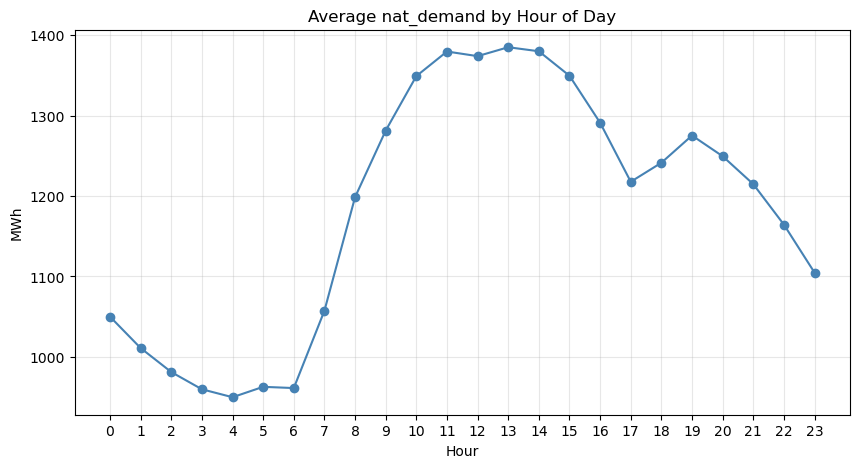

In [11]:
#trend hourly

plt.figure(figsize=(10, 5))
df_time.groupby(df_time.index.hour)['nat_demand'].mean().plot(color='steelblue', marker='o')
plt.title('Average nat_demand by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('MWh')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

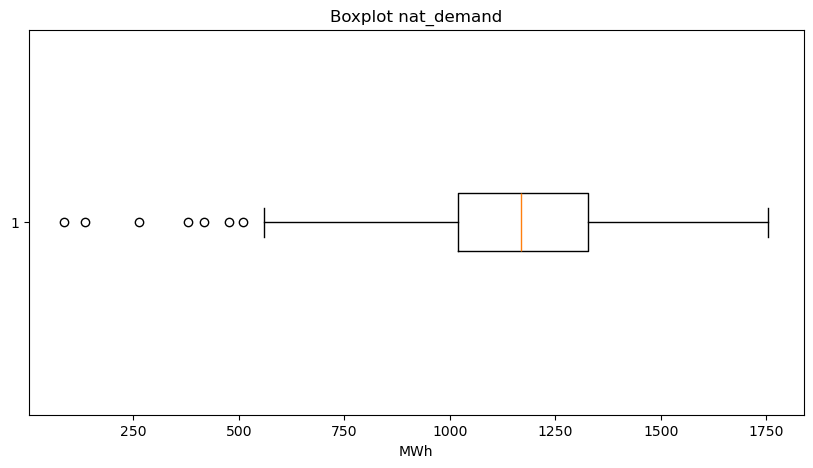

In [12]:
#boxplot

plt.figure(figsize=(10, 5))
plt.boxplot(df['nat_demand'], vert=False)
plt.title('Boxplot nat_demand')
plt.xlabel('MWh')
plt.show()

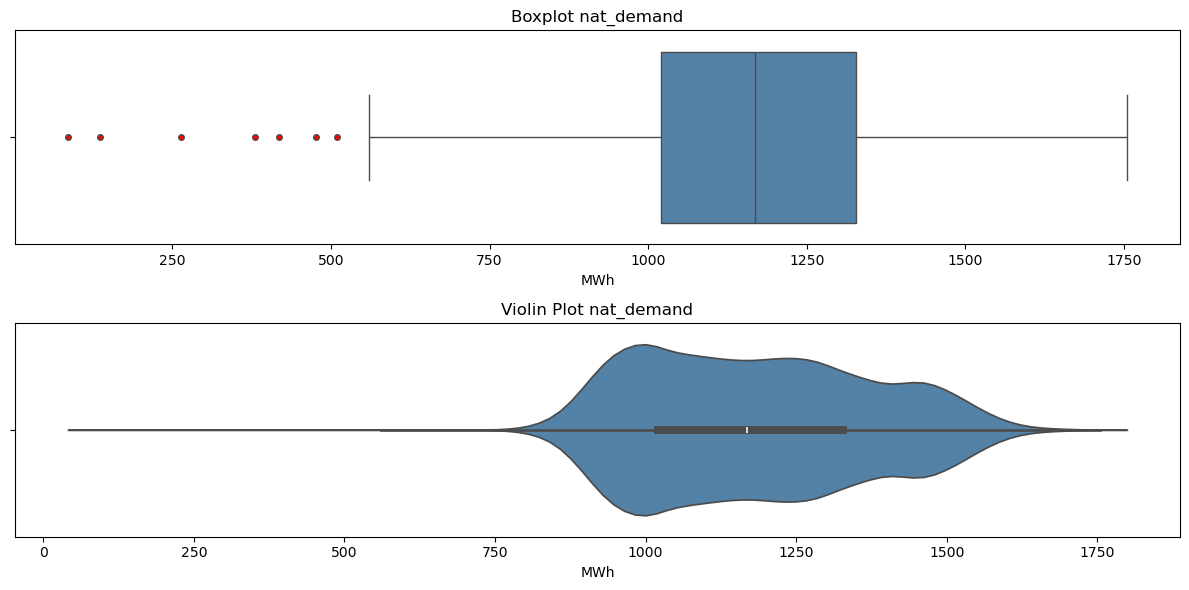

In [13]:
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Boxplot
sns.boxplot(x=df['nat_demand'], ax=axes[0], color='steelblue', flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
axes[0].set_title('Boxplot nat_demand')
axes[0].set_xlabel('MWh')

# Violin plot 
sns.violinplot(x=df['nat_demand'], ax=axes[1], color='steelblue')
axes[1].set_title('Violin Plot nat_demand')
axes[1].set_xlabel('MWh')

plt.tight_layout()
plt.show()

In [14]:
#check outlier

Q1 = df['nat_demand'].quantile(0.25)
Q3 = df['nat_demand'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[df['nat_demand'] < Q1 - 1.5*IQR]
print(f"Below fence outlier: {len(outliers)}")
print(outliers[['nat_demand']].sort_values('nat_demand'))

Below fence outlier: 7
       nat_demand
35483     85.1925
35484    135.7636
35485    263.6183
21755    380.5936
35486    417.4492
35487    475.8024
520      509.8358


In [15]:
outliers_df = outliers.sort_values('nat_demand')
outliers_df

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
35483,2019-01-20 12:00:00,85.1925,29.394678,0.016237,0.033951,24.225527,29.144678,0.016504,0.202942,12.431692,29.144678,0.014662,0.050812,1.413640,0,0,0
35484,2019-01-20 13:00:00,135.7636,29.294672,0.016032,0.062653,24.641796,29.372797,0.016513,0.125244,14.316523,29.435297,0.014899,0.084290,1.615353,0,0,0
35485,2019-01-20 14:00:00,263.6183,28.969019,0.015850,0.067841,25.936263,29.547144,0.016460,0.057800,15.979043,29.187769,0.014873,0.114075,1.949015,0,0,0
21755,2017-06-27 12:00:00,380.5936,28.446252,0.017640,0.113861,5.408851,27.977502,0.019158,0.256470,5.553203,26.618127,0.017243,0.255127,3.294285,0,0,1
35486,2019-01-20 15:00:00,417.4492,28.403619,0.015743,0.046555,27.945601,29.544244,0.016437,0.035233,16.643166,28.419244,0.014809,0.118805,2.599067,0,0,0
35487,2019-01-20 16:00:00,475.8024,27.655542,0.015736,0.025024,29.566897,28.780542,0.016301,0.044052,15.792458,27.405542,0.014706,0.113037,3.379718,0,0,0
520,2015-01-24 17:00:00,509.8358,27.034692,0.016271,0.194885,22.125257,28.706567,0.016065,0.099915,7.182586,25.456567,0.015714,0.086212,0.728335,0,0,0


In [16]:
#drop outlier

outlier_timestamps = df_time.iloc[[35483, 35484, 35485, 21755, 35486, 35487, 520]].index

# df_clean = df.drop(outliers_df.index)
df_clean = df_time.drop(outlier_timestamps)
print(f"Rows before: {len(df_time)}, Rows after: {len(df_clean)}")

Rows before: 48048, Rows after: 48041


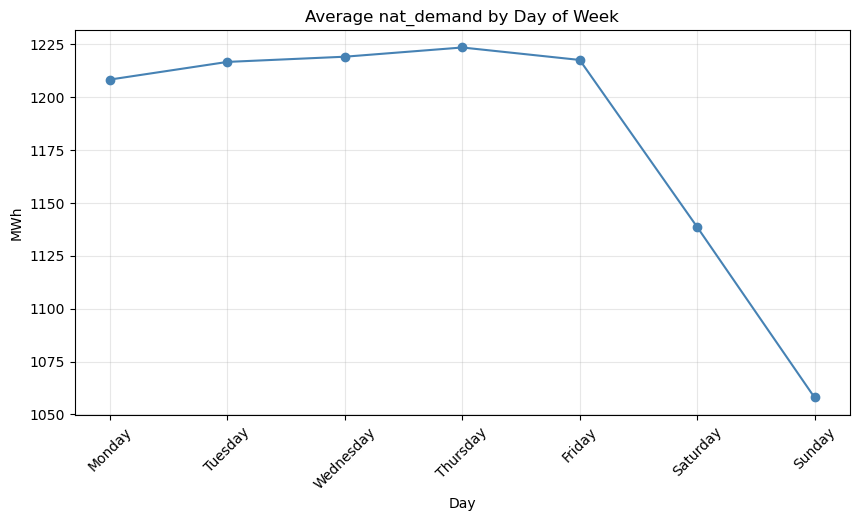

In [17]:
#day-of-week pattern

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
df_clean.groupby(df_clean.index.dayofweek)['nat_demand'].mean().plot(color='steelblue', marker='o')
plt.title('Average nat_demand by Day of Week')
plt.xlabel('Day')
plt.ylabel('MWh')
plt.xticks(range(7), days, rotation=45)
plt.grid(alpha=0.3)
plt.show()

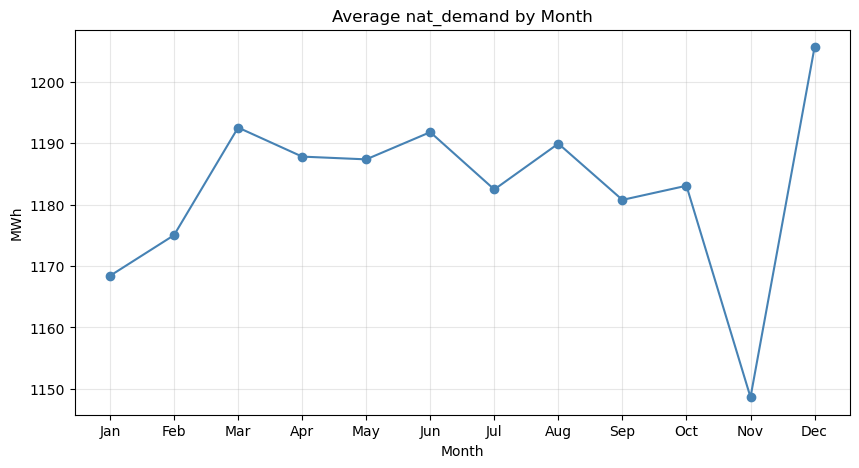

In [18]:
#monthly pattern

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 5))
df_clean.groupby(df_clean.index.month)['nat_demand'].mean().plot(color='steelblue', marker='o')
plt.title('Average nat_demand by Month')
plt.xlabel('Month')
plt.ylabel('MWh')
plt.xticks(range(1, 13), months)
plt.grid(alpha=0.3)
plt.show()

<Figure size 1600x500 with 0 Axes>

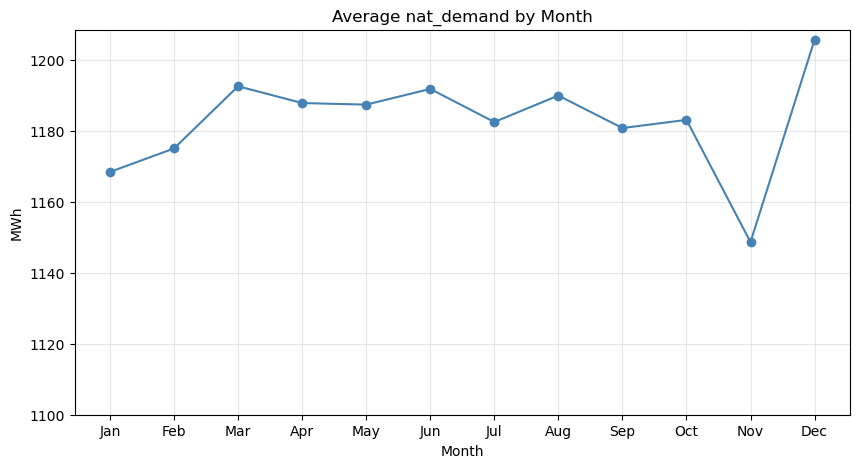

In [19]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig= plt.figure(figsize=(16, 5))

# settig ylim
plt.figure(figsize=(10, 5))
df_clean.groupby(df_clean.index.month)['nat_demand'].mean().plot(color='steelblue', marker='o')
plt.title('Average nat_demand by Month')
plt.xlabel('Month')
plt.ylabel('MWh')
plt.xticks(range(1, 13), months)
plt.ylim(1100)
plt.grid(alpha=0.3)
plt.show()

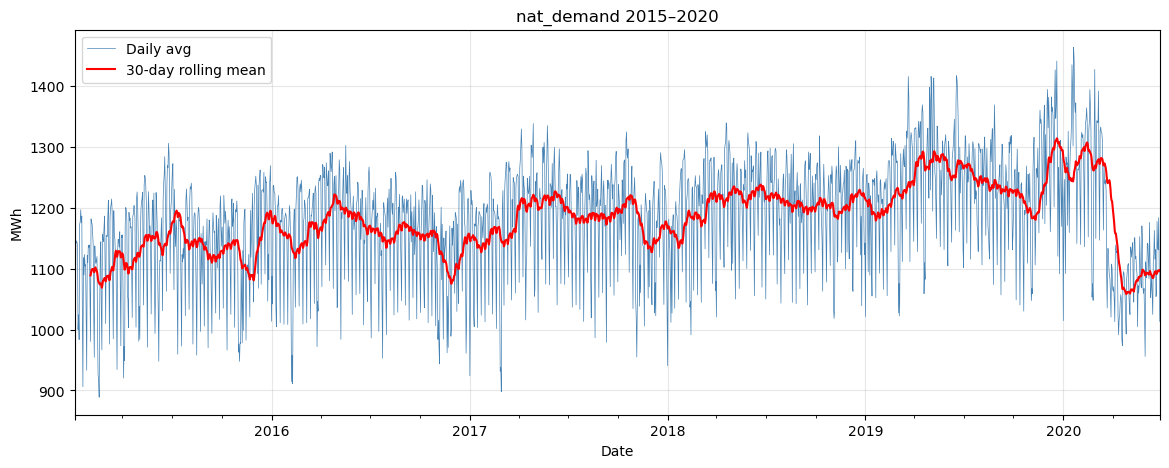

In [20]:
#full time series plot

plt.figure(figsize=(14, 5))
df_clean['nat_demand'].resample('D').mean().plot(color='steelblue', linewidth=0.5, label='Daily avg')
df_clean['nat_demand'].resample('D').mean().rolling(30).mean().plot(color='red', linewidth=1.5, label='30-day rolling mean')
plt.title('nat_demand 2015–2020')
plt.xlabel('Date')
plt.ylabel('MWh')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

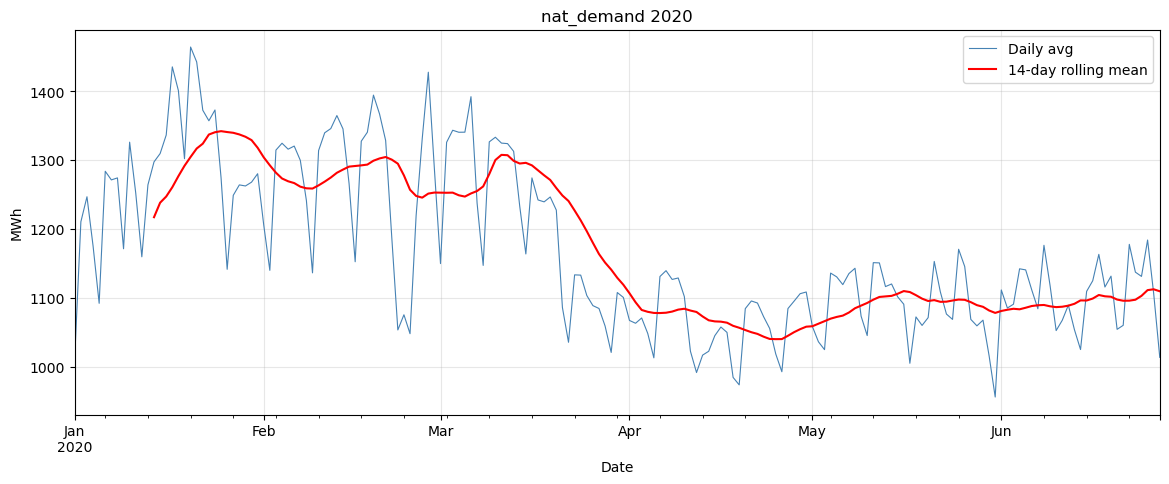

In [21]:
# Zoom ke 2020
plt.figure(figsize=(14, 5))
df_2020 = df_clean.loc['2020-01-01':'2020-12-31']
df_2020['nat_demand'].resample('D').mean().plot(color='steelblue', linewidth=0.8, label='Daily avg')
df_2020['nat_demand'].resample('D').mean().rolling(14).mean().plot(color='red', linewidth=1.5, label='14-day rolling mean')
plt.title('nat_demand 2020')
plt.xlabel('Date')
plt.ylabel('MWh')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

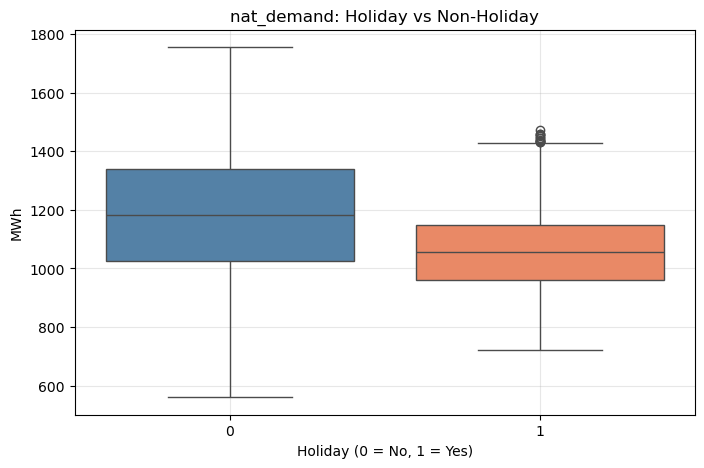

In [22]:
#holiday effect


plt.figure(figsize=(8, 5))
sns.boxplot(x='holiday', y='nat_demand', data=df_clean.reset_index(),
            hue='holiday', palette=['steelblue', 'coral'], legend=False)
plt.title('nat_demand: Holiday vs Non-Holiday')
plt.xlabel('Holiday (0 = No, 1 = Yes)')
plt.ylabel('MWh')
plt.grid(alpha=0.3)
plt.show()

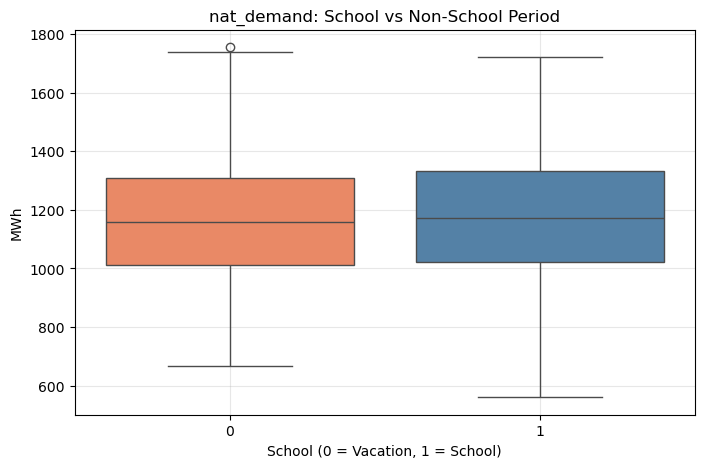

In [23]:
#school period effect

plt.figure(figsize=(8, 5))
sns.boxplot(x='school', y='nat_demand', data=df_clean.reset_index(),
            hue='school', palette=['coral', 'steelblue'], legend=False)
plt.title('nat_demand: School vs Non-School Period')
plt.xlabel('School (0 = Vacation, 1 = School)')
plt.ylabel('MWh')
plt.grid(alpha=0.3)
plt.show()

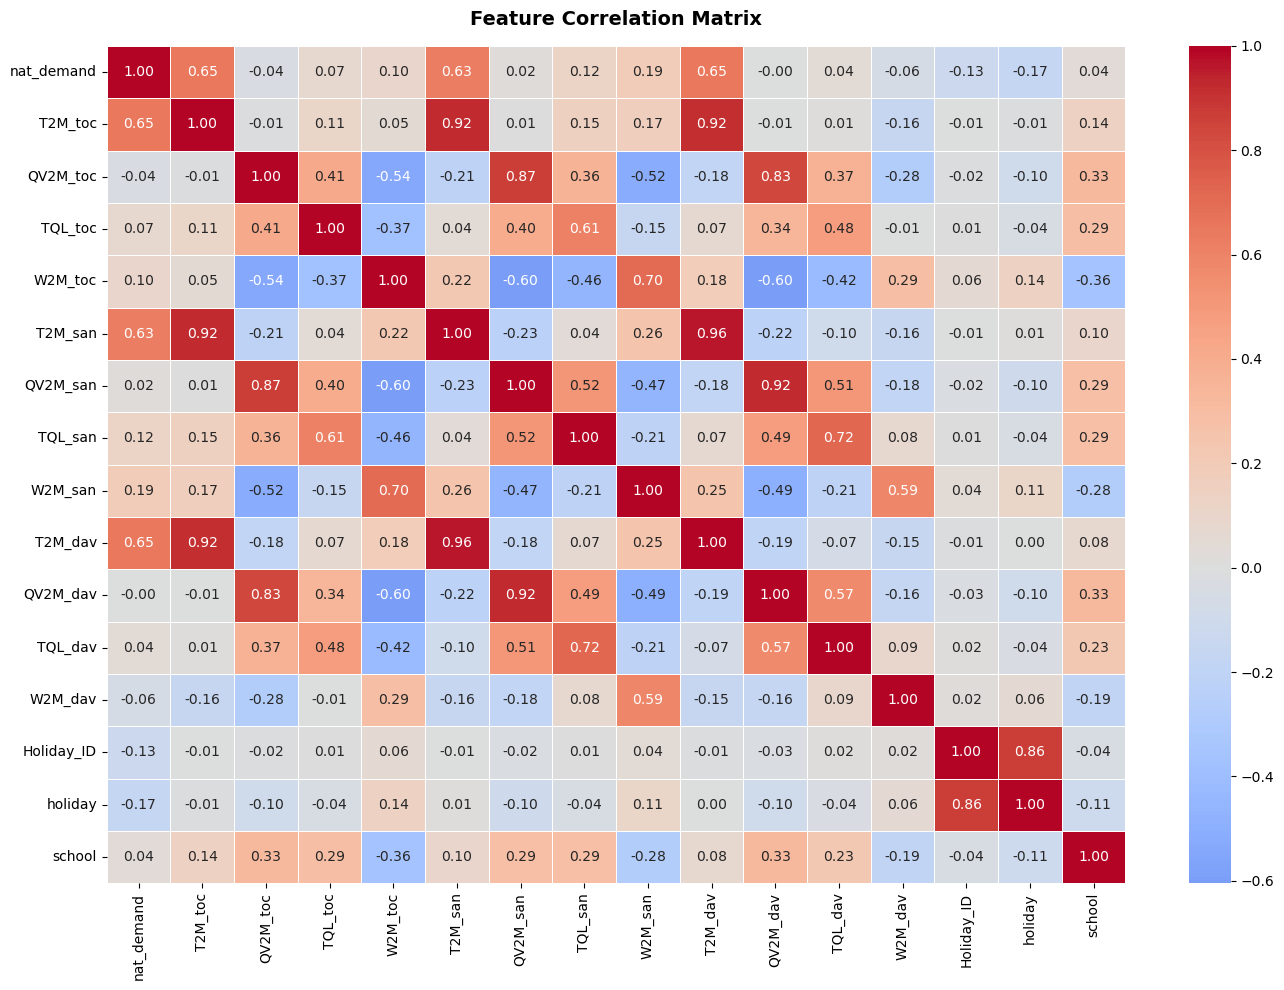

In [24]:
#correlation

plt.figure(figsize=(14, 10))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Feature Engineering

In [25]:
#extract temporal features

df_fe = df_clean.copy()

# Temporal features
df_fe['hour'] = df_fe.index.hour
df_fe['dayofweek'] = df_fe.index.dayofweek
df_fe['month'] = df_fe.index.month
df_fe['is_weekend'] = (df_fe.index.dayofweek >= 5).astype(int)

# Cyclical encoding
import numpy as np
df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour'] / 24)
df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour'] / 24)
df_fe['dow_sin'] = np.sin(2 * np.pi * df_fe['dayofweek'] / 7)
df_fe['dow_cos'] = np.cos(2 * np.pi * df_fe['dayofweek'] / 7)
df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

print(df_fe.shape)
df_fe.head()

(48041, 26)


,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,...,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
datetime,,,,,,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,...,1,5,1,1,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,...,2,5,1,1,0.500000,0.866025,-0.974928,-0.222521,0.5,0.866025
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,...,3,5,1,1,0.707107,0.707107,-0.974928,-0.222521,0.5,0.866025
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,...,4,5,1,1,0.866025,0.500000,-0.974928,-0.222521,0.5,0.866025
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,...,5,5,1,1,0.965926,0.258819,-0.974928,-0.222521,0.5,0.866025


In [26]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48041 entries, 2015-01-03 01:00:00 to 2020-06-27 00:00:00
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   nat_demand  48041 non-null  float64
 1   T2M_toc     48041 non-null  float64
 2   QV2M_toc    48041 non-null  float64
 3   TQL_toc     48041 non-null  float64
 4   W2M_toc     48041 non-null  float64
 5   T2M_san     48041 non-null  float64
 6   QV2M_san    48041 non-null  float64
 7   TQL_san     48041 non-null  float64
 8   W2M_san     48041 non-null  float64
 9   T2M_dav     48041 non-null  float64
 10  QV2M_dav    48041 non-null  float64
 11  TQL_dav     48041 non-null  float64
 12  W2M_dav     48041 non-null  float64
 13  Holiday_ID  48041 non-null  int64  
 14  holiday     48041 non-null  int64  
 15  school      48041 non-null  int64  
 16  hour        48041 non-null  int32  
 17  dayofweek   48041 non-null  int32  
 18  month       48041 non-null  int

In [27]:
#lag features

for lag in [72, 96, 120, 144, 168]:
    df_fe[f'lag_{lag}'] = df_fe['nat_demand'].shift(lag)

# Rolling statistics (window dari lag-72 ke belakang)
df_fe['rolling_mean_72'] = df_fe['nat_demand'].shift(72).rolling(window=24).mean()
df_fe['rolling_std_72'] = df_fe['nat_demand'].shift(72).rolling(window=24).std()

# Drop NaN yang muncul akibat lag
df_fe = df_fe.dropna()

print(df_fe.shape)

(47873, 33)


In [28]:
df_fe

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,...,dow_cos,month_sin,month_cos,lag_72,lag_96,lag_120,lag_144,lag_168,rolling_mean_72,rolling_std_72
datetime,,,,,,,,,,,,,,,,,,,,,
2015-01-10 01:00:00,906.9580,24.976495,0.017215,0.025253,21.335333,23.554620,0.016421,0.051376,12.485627,22.288995,...,-0.222521,5.000000e-01,0.866025,940.4568,914.6895,928.5338,944.0556,970.3450,1146.473625,202.630546
2015-01-10 02:00:00,863.5135,24.906274,0.017337,0.034378,22.177057,23.429712,0.016337,0.038712,12.949576,22.296899,...,-0.222521,5.000000e-01,0.866025,908.5931,890.8448,901.5402,928.7193,912.1755,1147.213137,201.687242
2015-01-10 03:00:00,848.4447,24.879724,0.017512,0.045349,22.742188,23.309412,0.016292,0.028526,13.091533,22.325037,...,-0.222521,5.000000e-01,0.866025,886.4675,869.0447,887.7822,909.5566,900.2688,1147.939088,200.671271
2015-01-10 04:00:00,839.8821,24.907922,0.017673,0.047501,22.630025,23.306360,0.016337,0.016182,13.050650,22.368860,...,-0.222521,5.000000e-01,0.866025,876.4283,852.4821,881.0019,894.6543,889.9538,1148.936846,199.192439
2015-01-10 05:00:00,847.1073,24.932520,0.017795,0.036087,21.731658,23.354395,0.016422,0.009590,12.846088,22.424707,...,-0.222521,5.000000e-01,0.866025,892.4143,891.2575,885.4197,884.6659,893.6865,1148.985046,199.127505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-26 20:00:00,1128.5592,27.246545,0.020303,0.055511,9.289304,25.715295,0.019746,0.121552,1.990773,23.746545,...,-0.900969,1.224647e-16,-1.000000,1125.1268,1273.0326,1298.8818,1157.6162,1207.3977,1154.635842,101.602523
2020-06-26 21:00:00,1112.7488,27.099573,0.020395,0.053848,9.837504,25.552698,0.019632,0.153870,2.094459,23.693323,...,-0.900969,1.224647e-16,-1.000000,1114.4679,1278.9725,1305.3179,1159.0047,1175.9687,1147.781483,98.346538
2020-06-26 22:00:00,1081.5680,26.971155,0.020448,0.057251,10.262464,25.393030,0.019518,0.144531,2.396369,23.658655,...,-0.900969,1.224647e-16,-1.000000,1088.2161,1232.4834,1259.3089,1119.9120,1123.2326,1141.770346,97.348180


In [29]:
# # Create target variables for 12h and 24h forecast horizons
# for h in [12, 24]:
#     df_fe[f'target_{h}h'] = df_fe['nat_demand'].shift(-h)

# # Drop NaN rows created by negative shift
# df_fe = df_fe.dropna()

# print(df_fe.shape)
# print(df_fe[['nat_demand', 'target_12h', 'target_24h']].head(30))

# Create target variables for 1h and 6h forecast horizons
for h in [1, 6]:
    df_fe[f'target_{h}h'] = df_fe['nat_demand'].shift(-h)

# Drop NaN rows created by negative shift
df_fe = df_fe.dropna()

print(df_fe.shape)
print(df_fe[['nat_demand', 'target_1h', 'target_6h']].head(10))

(47867, 35)
                     nat_demand  target_1h  target_6h
datetime                                             
2015-01-10 01:00:00    906.9580   863.5135   897.8229
2015-01-10 02:00:00    863.5135   848.4447  1021.6720
2015-01-10 03:00:00    848.4447   839.8821  1108.9439
2015-01-10 04:00:00    839.8821   847.1073  1165.4756
2015-01-10 05:00:00    847.1073   848.4718  1179.0630
2015-01-10 06:00:00    848.4718   897.8229  1173.0899
2015-01-10 07:00:00    897.8229  1021.6720  1161.4116
2015-01-10 08:00:00   1021.6720  1108.9439  1133.3133
2015-01-10 09:00:00   1108.9439  1165.4756  1100.6097
2015-01-10 10:00:00   1165.4756  1179.0630  1082.6875


In [30]:
pd.set_option('display.max_columns', None)
df_fe

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,lag_72,lag_96,lag_120,lag_144,lag_168,rolling_mean_72,rolling_std_72,target_1h,target_6h
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-10 01:00:00,906.9580,24.976495,0.017215,0.025253,21.335333,23.554620,0.016421,0.051376,12.485627,22.288995,0.015735,0.121826,6.229961,0,0,0,1,5,1,1,0.258819,9.659258e-01,-0.974928,-0.222521,5.000000e-01,0.866025,940.4568,914.6895,928.5338,944.0556,970.3450,1146.473625,202.630546,863.5135,897.8229
2015-01-10 02:00:00,863.5135,24.906274,0.017337,0.034378,22.177057,23.429712,0.016337,0.038712,12.949576,22.296899,0.015712,0.117706,6.395434,0,0,0,2,5,1,1,0.500000,8.660254e-01,-0.974928,-0.222521,5.000000e-01,0.866025,908.5931,890.8448,901.5402,928.7193,912.1755,1147.213137,201.687242,848.4447,1021.6720
2015-01-10 03:00:00,848.4447,24.879724,0.017512,0.045349,22.742188,23.309412,0.016292,0.028526,13.091533,22.325037,0.015704,0.123718,6.426799,0,0,0,3,5,1,1,0.707107,7.071068e-01,-0.974928,-0.222521,5.000000e-01,0.866025,886.4675,869.0447,887.7822,909.5566,900.2688,1147.939088,200.671271,839.8821,1108.9439
2015-01-10 04:00:00,839.8821,24.907922,0.017673,0.047501,22.630025,23.306360,0.016337,0.016182,13.050650,22.368860,0.015704,0.123779,6.351922,0,0,0,4,5,1,1,0.866025,5.000000e-01,-0.974928,-0.222521,5.000000e-01,0.866025,876.4283,852.4821,881.0019,894.6543,889.9538,1148.936846,199.192439,847.1073,1165.4756
2015-01-10 05:00:00,847.1073,24.932520,0.017795,0.036087,21.731658,23.354395,0.016422,0.009590,12.846088,22.424707,0.015735,0.118378,6.165582,0,0,0,5,5,1,1,0.965926,2.588190e-01,-0.974928,-0.222521,5.000000e-01,0.866025,892.4143,891.2575,885.4197,884.6659,893.6865,1148.985046,199.127505,848.4718,1179.0630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-26 14:00:00,1220.4969,28.718103,0.019242,0.117004,5.991976,28.624353,0.019616,0.114349,6.485374,25.999353,0.018335,0.180176,1.449518,0,0,1,14,4,6,0,-0.500000,-8.660254e-01,-0.433884,-0.900969,1.224647e-16,-1.000000,1255.3198,1359.3101,1035.4303,1096.1403,1254.2509,1181.738608,110.219573,1183.0068,1128.5592
2020-06-26 15:00:00,1183.0068,28.605249,0.019059,0.131653,4.695789,28.417749,0.019845,0.110901,6.319467,25.792749,0.018480,0.177795,1.603448,0,0,1,15,4,6,0,-0.707107,-7.071068e-01,-0.433884,-0.900969,1.224647e-16,-1.000000,1189.3427,1320.4162,1098.8787,1082.7122,1230.3756,1176.277212,106.224261,1093.5472,1112.7488
2020-06-26 16:00:00,1093.5472,28.444696,0.019082,0.133484,5.504968,27.944696,0.020036,0.115814,5.650668,25.413446,0.018602,0.171692,1.992104,0,0,1,16,4,6,0,-0.866025,-5.000000e-01,-0.433884,-0.900969,1.224647e-16,-1.000000,1138.9366,1262.8703,1137.2244,1045.2069,1174.8661,1171.113308,104.834990,1055.9591,1081.5680


In [31]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 47867 entries, 2015-01-10 01:00:00 to 2020-06-26 18:00:00
Data columns (total 35 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   nat_demand       47867 non-null  float64
 1   T2M_toc          47867 non-null  float64
 2   QV2M_toc         47867 non-null  float64
 3   TQL_toc          47867 non-null  float64
 4   W2M_toc          47867 non-null  float64
 5   T2M_san          47867 non-null  float64
 6   QV2M_san         47867 non-null  float64
 7   TQL_san          47867 non-null  float64
 8   W2M_san          47867 non-null  float64
 9   T2M_dav          47867 non-null  float64
 10  QV2M_dav         47867 non-null  float64
 11  TQL_dav          47867 non-null  float64
 12  W2M_dav          47867 non-null  float64
 13  Holiday_ID       47867 non-null  int64  
 14  holiday          47867 non-null  int64  
 15  school           47867 non-null  int64  
 16  hour             47867 

## Normalization

In [32]:
# splits = [
#     # (train_start, train_end, val_start, val_end)
#     # Sliding window
#     ('2015-01', '2015-12', '2016-01', '2016-06'),
#     ('2016-01', '2016-12', '2017-01', '2017-06'),
#     ('2017-01', '2017-12', '2018-01', '2018-06'),
#     ('2018-01', '2018-12', '2019-01', '2019-06'),
#     ('2019-01', '2019-12', '2020-01', '2020-06'),
# ]

In [33]:
# splits_expanding = [
#     ('2015-01', '2015-12', '2016-01', '2016-06'),
#     ('2015-01', '2016-12', '2017-01', '2017-06'),
#     ('2015-01', '2017-12', '2018-01', '2018-06'),
#     ('2015-01', '2018-12', '2019-01', '2019-06'),
#     ('2015-01', '2019-12', '2020-01', '2020-06'),
# ]


splits_expanding = [
    ('2015-01', '2015-12', '2016-01', '2016-12'),
    ('2015-01', '2016-12', '2017-01', '2017-12'),
    ('2015-01', '2017-12', '2018-01', '2018-12'),
    ('2015-01', '2018-12', '2019-01', '2019-12'),
]

print("Splits updated!")

Splits updated!


In [34]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = [col for col in df_fe.columns if col not in ['target_1h', 'target_6h']]

def prepare_fold(df, train_start, train_end, val_start, val_end, target_col):
    train = df.loc[train_start:train_end]
    val = df.loc[val_start:val_end]
    
    # Normalize per fold (no leakage)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_train = scaler_X.fit_transform(train[feature_cols])
    X_val = scaler_X.transform(val[feature_cols])
    
    y_train = scaler_y.fit_transform(train[[target_col]])
    y_val = scaler_y.transform(val[[target_col]])
    
    return X_train, X_val, y_train, y_val, scaler_y

print("prepare_fold function defined!")

prepare_fold function defined!


In [43]:
# #GRU architecture

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout

# def build_gru_model(input_shape):
#     model = Sequential([
#         GRU(64, return_sequences=True, input_shape=input_shape),
#         Dropout(0.2),
#         GRU(32, return_sequences=False),
#         Dropout(0.2),
#         Dense(1)
#     ])
#     model.compile(optimizer='adam', loss='mse', metrics=['mae'])
#     return model

# print("GRU model function defined!")


# from tensorflow.keras.layers import Input

# def build_gru_model(input_shape):
#     inputs = Input(shape=input_shape)
#     x = GRU(64, return_sequences=True)(inputs)
#     x = Dropout(0.2)(x)
#     x = GRU(32, return_sequences=False)(x)
#     x = Dropout(0.2)(x)
#     outputs = Dense(1)(x)
    
#     model = tf.keras.Model(inputs, outputs)
#     model.compile(optimizer='adam', loss='mse', metrics=['mae'])
#     return model

def build_gru_model(input_shape, n_layers=2):
    inputs = Input(shape=input_shape)
    
    if n_layers == 1:  # 3 layer total
        x = GRU(64, return_sequences=False)(inputs)
        x = Dropout(0.2)(x)
    elif n_layers == 2:  # 5 layer total
        x = GRU(64, return_sequences=True)(inputs)
        x = Dropout(0.2)(x)
        x = GRU(32, return_sequences=False)(x)
        x = Dropout(0.2)(x)
    elif n_layers == 3:  # 7 layer total
        x = GRU(128, return_sequences=True)(inputs)
        x = Dropout(0.2)(x)
        x = GRU(64, return_sequences=True)(x)
        x = Dropout(0.2)(x)
        x = GRU(32, return_sequences=False)(x)
        x = Dropout(0.2)(x)
    
    outputs = Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

print("build_gru_model updated!")

build_gru_model updated!


In [44]:
#reshape input to 3D

def reshape_for_gru(X):
    # GRU expects (samples, timesteps, features)
    # Kita treat setiap row sebagai 1 timestep
    return X.reshape((X.shape[0], 1, X.shape[1]))

print("reshape function defined!")

reshape function defined!


In [45]:
# #12hr horizon

# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np

# def run_cv(splits, target_col, cv_name):
#     results = []
    
#     for i, (train_start, train_end, val_start, val_end) in enumerate(splits):
#         print(f"\n{cv_name} - Fold {i+1}: Train {train_start}–{train_end} | Val {val_start}–{val_end}")
        
#         # Prepare data
#         X_train, X_val, y_train, y_val, scaler_y = prepare_fold(
#             df_fe, train_start, train_end, val_start, val_end, target_col)
        
#         # Reshape for GRU
#         X_train_3d = reshape_for_gru(X_train)
#         X_val_3d = reshape_for_gru(X_val)
        
#         # Build & train model
#         model = build_gru_model((X_train_3d.shape[1], X_train_3d.shape[2]))
#         model.fit(X_train_3d, y_train, epochs=20, batch_size=64, verbose=0)
        
#         # Predict & inverse transform
#         y_pred_scaled = model.predict(X_val_3d, verbose=0)
#         y_pred = scaler_y.inverse_transform(y_pred_scaled)
#         y_true = scaler_y.inverse_transform(y_val)
        
#         # Metrics
#         mae = mean_absolute_error(y_true, y_pred)
#         rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#         mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        
#         results.append({'fold': i+1, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape})
#         print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")
    
#     return pd.DataFrame(results)

# print("run_cv function defined!")

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def run_cv(splits, target_col, cv_name, n_layers=2):
    results = []
    
    for i, (train_start, train_end, val_start, val_end) in enumerate(splits):
        print(f"\n{cv_name} | layers={n_layers} - Fold {i+1}: Train {train_start}–{train_end} | Val {val_start}–{val_end}")
        
        X_train, X_val, y_train, y_val, scaler_y = prepare_fold(
            df_fe, train_start, train_end, val_start, val_end, target_col)
        
        X_train_3d = reshape_for_gru(X_train)
        X_val_3d = reshape_for_gru(X_val)
        
        model = build_gru_model((X_train_3d.shape[1], X_train_3d.shape[2]), n_layers=n_layers)
        model.fit(X_train_3d, y_train,
                  epochs=50,
                  batch_size=64,
                  validation_data=(X_val_3d, y_val),
                  callbacks=callbacks,
                  verbose=0)
        
        y_pred_scaled = model.predict(X_val_3d, verbose=0)
        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        y_true = scaler_y.inverse_transform(y_val)
        
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        
        results.append({'fold': i+1, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape})
        print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")
    
    return pd.DataFrame(results)

print("run_cv updated!")

run_cv updated!


In [47]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print("Callbacks defined!")

Callbacks defined!


In [48]:
# Run CV untuk 3 arsitektur
results_1layer = run_cv(splits_expanding, 'target_1h', 'GRU-1layer', n_layers=1)
results_2layer = run_cv(splits_expanding, 'target_1h', 'GRU-2layer', n_layers=2)
results_3layer = run_cv(splits_expanding, 'target_1h', 'GRU-3layer', n_layers=3)


GRU-1layer | layers=1 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
MAE: 26.35 | RMSE: 34.76 | MAPE: 2.25%

GRU-1layer | layers=1 - Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
MAE: 55.37 | RMSE: 69.74 | MAPE: 4.68%

GRU-1layer | layers=1 - Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
MAE: 53.86 | RMSE: 66.31 | MAPE: 4.48%

GRU-1layer | layers=1 - Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
MAE: 51.13 | RMSE: 64.20 | MAPE: 4.03%

GRU-2layer | layers=2 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
MAE: 60.68 | RMSE: 75.01 | MAPE: 5.26%

GRU-2layer | layers=2 - Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
MAE: 46.70 | RMSE: 59.63 | MAPE: 4.01%

GRU-2layer | layers=2 - Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
MAE: 23.69 | RMSE: 31.62 | MAPE: 1.95%

GRU-2layer | layers=2 - Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
MAE: 48.45 | RMSE: 60.60 | MAPE: 3.88%

GRU-3layer | layers=3 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–201

In [49]:
results_1layer['architecture'] = 'GRU-1layer'
results_2layer['architecture'] = 'GRU-2layer'
results_3layer['architecture'] = 'GRU-3layer'

all_arch = pd.concat([results_1layer, results_2layer, results_3layer])
summary_arch = all_arch.groupby('architecture')[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print(summary_arch)

                MAE   RMSE  MAPE
architecture                    
GRU-1layer    46.68  58.75  3.86
GRU-2layer    44.88  56.72  3.77
GRU-3layer    50.34  63.01  4.20


In [50]:
results_1layer_6h = run_cv(splits_expanding, 'target_6h', 'GRU-1layer', n_layers=1)
results_2layer_6h = run_cv(splits_expanding, 'target_6h', 'GRU-2layer', n_layers=2)
results_3layer_6h = run_cv(splits_expanding, 'target_6h', 'GRU-3layer', n_layers=3)


GRU-1layer | layers=1 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
MAE: 95.70 | RMSE: 117.79 | MAPE: 8.26%

GRU-1layer | layers=1 - Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
MAE: 83.39 | RMSE: 99.77 | MAPE: 7.09%

GRU-1layer | layers=1 - Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
MAE: 84.51 | RMSE: 101.07 | MAPE: 6.94%

GRU-1layer | layers=1 - Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
MAE: 87.65 | RMSE: 105.82 | MAPE: 6.87%

GRU-2layer | layers=2 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
MAE: 96.58 | RMSE: 116.62 | MAPE: 8.21%

GRU-2layer | layers=2 - Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
MAE: 81.93 | RMSE: 98.64 | MAPE: 6.89%

GRU-2layer | layers=2 - Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
MAE: 79.44 | RMSE: 95.36 | MAPE: 6.47%

GRU-2layer | layers=2 - Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
MAE: 76.98 | RMSE: 93.68 | MAPE: 6.05%

GRU-3layer | layers=3 - Fold 1: Train 2015-01–2015-12 | Val 2016-01

In [51]:
results_1layer_6h['architecture'] = 'GRU-1layer'
results_2layer_6h['architecture'] = 'GRU-2layer'
results_3layer_6h['architecture'] = 'GRU-3layer'

all_arch_6h = pd.concat([results_1layer_6h, results_2layer_6h, results_3layer_6h])
summary_arch_6h = all_arch_6h.groupby('architecture')[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print("Horizon 6h:")
print(summary_arch_6h)

Horizon 6h:
                MAE    RMSE  MAPE
architecture                     
GRU-1layer    87.81  106.11  7.29
GRU-2layer    83.73  101.08  6.91
GRU-3layer    77.61   94.15  6.37


In [52]:
# Train model

# Final model - horizon 1h (GRU-2layer)
# Train: 2015-2019, Test: 2020-01 to 2020-03

train_final = df_fe.loc['2015-01':'2019-12']
test_final = df_fe.loc['2020-01':'2020-03']

# Normalize
scaler_X_final = MinMaxScaler()
scaler_y_final = MinMaxScaler()

train_final_scaled = train_final.copy()
test_final_scaled = test_final.copy()

train_final_scaled[feature_cols] = scaler_X_final.fit_transform(train_final[feature_cols])
test_final_scaled[feature_cols] = scaler_X_final.transform(test_final[feature_cols])

y_train_final = scaler_y_final.fit_transform(train_final[['target_1h']])
y_test_final = scaler_y_final.transform(test_final[['target_1h']])

X_train_final = reshape_for_gru(train_final_scaled[feature_cols].values)
X_test_final = reshape_for_gru(test_final_scaled[feature_cols].values)

print(f"X_train: {X_train_final.shape}")
print(f"X_test: {X_test_final.shape}")

X_train: (43600, 1, 33)
X_test: (2184, 1, 33)


In [53]:
# Train final model 1h
final_model_1h = build_gru_model((X_train_final.shape[1], X_train_final.shape[2]), n_layers=2)

history_1h = final_model_1h.fit(
    X_train_final, y_train_final,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 957us/step - loss: 0.0128 - mae: 0.0814 - val_loss: 0.0024 - val_mae: 0.0389 - learning_rate: 0.0010
Epoch 2/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step - loss: 0.0045 - mae: 0.0525 - val_loss: 0.0015 - val_mae: 0.0306 - learning_rate: 0.0010
Epoch 3/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - loss: 0.0032 - mae: 0.0436 - val_loss: 0.0012 - val_mae: 0.0267 - learning_rate: 0.0010
Epoch 4/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - loss: 0.0025 - mae: 0.0383 - val_loss: 0.0011 - val_mae: 0.0259 - learning_rate: 5.0000e-04
Epoch 5/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step - loss: 0.0022 - mae: 0.0358 - val_loss: 0.0011 - val_mae: 0.0258 - learning_rate: 5.0000e-04


In [54]:
# Evaluate final model 1h
y_pred_1h_scaled = final_model_1h.predict(X_test_final, verbose=0)
y_pred_1h = scaler_y_final.inverse_transform(y_pred_1h_scaled)
y_true_1h = scaler_y_final.inverse_transform(y_test_final)

mae_1h = mean_absolute_error(y_true_1h, y_pred_1h)
rmse_1h = np.sqrt(mean_squared_error(y_true_1h, y_pred_1h))
mape_1h = np.mean(np.abs((y_true_1h - y_pred_1h) / y_true_1h)) * 100

print("Final Model - Horizon 1h (Test set: Jan-Mar 2020):")
print(f"MAE:  {mae_1h:.2f} MWh")
print(f"RMSE: {rmse_1h:.2f} MWh")
print(f"MAPE: {mape_1h:.2f}%")

Final Model - Horizon 1h (Test set: Jan-Mar 2020):
MAE:  54.39 MWh
RMSE: 70.65 MWh
MAPE: 4.36%


In [55]:
# Final model - horizon 6h (GRU-3layer)
y_train_final_6h = scaler_y_final.fit_transform(train_final[['target_6h']])
y_test_final_6h = scaler_y_final.transform(test_final[['target_6h']])

final_model_6h = build_gru_model((X_train_final.shape[1], X_train_final.shape[2]), n_layers=3)

history_6h = final_model_6h.fit(
    X_train_final, y_train_final_6h,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0137 - mae: 0.0867 - val_loss: 0.0065 - val_mae: 0.0678 - learning_rate: 0.0010
Epoch 2/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0053 - mae: 0.0567 - val_loss: 0.0035 - val_mae: 0.0475 - learning_rate: 0.0010
Epoch 3/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0042 - mae: 0.0502 - val_loss: 0.0028 - val_mae: 0.0413 - learning_rate: 0.0010
Epoch 4/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0035 - mae: 0.0455 - val_loss: 0.0027 - val_mae: 0.0407 - learning_rate: 5.0000e-04
Epoch 5/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0032 - mae: 0.0437 - val_loss: 0.0027 - val_mae: 0.0407 - learning_rate: 5.0000e-04


In [56]:
# Evaluate final model 6h
y_pred_6h_scaled = final_model_6h.predict(X_test_final, verbose=0)
y_pred_6h = scaler_y_final.inverse_transform(y_pred_6h_scaled)
y_true_6h = scaler_y_final.inverse_transform(y_test_final_6h)

mae_6h = mean_absolute_error(y_true_6h, y_pred_6h)
rmse_6h = np.sqrt(mean_squared_error(y_true_6h, y_pred_6h))
mape_6h = np.mean(np.abs((y_true_6h - y_pred_6h) / y_true_6h)) * 100

print("Final Model - Horizon 6h (Test set: Jan-Mar 2020):")
print(f"MAE:  {mae_6h:.2f} MWh")
print(f"RMSE: {rmse_6h:.2f} MWh")
print(f"MAPE: {mape_6h:.2f}%")

Final Model - Horizon 6h (Test set: Jan-Mar 2020):
MAE:  94.36 MWh
RMSE: 116.71 MWh
MAPE: 7.47%


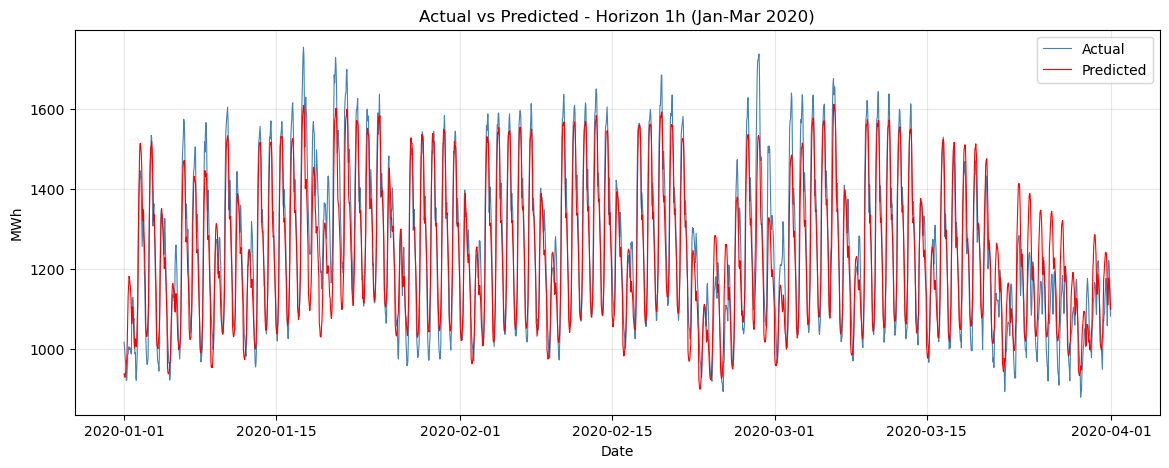

In [57]:
#horizon 1 hour

plt.figure(figsize=(14, 5))
plt.plot(test_final.index, y_true_1h, color='steelblue', linewidth=0.8, label='Actual')
plt.plot(test_final.index, y_pred_1h, color='red', linewidth=0.8, label='Predicted')
plt.title('Actual vs Predicted - Horizon 1h (Jan-Mar 2020)')
plt.xlabel('Date')
plt.ylabel('MWh')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

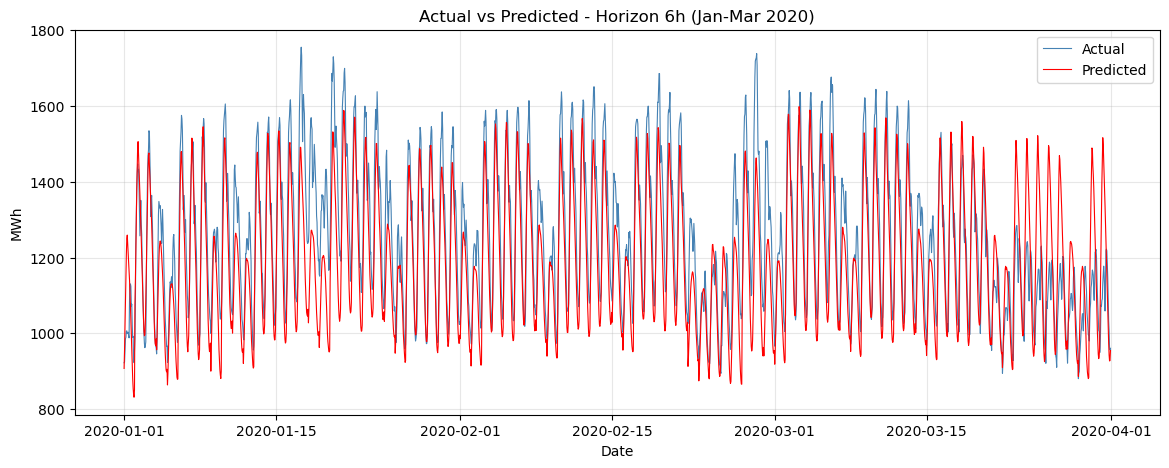

In [58]:
# horizon 6 hour
plt.figure(figsize=(14, 5))
plt.plot(test_final.index, y_true_6h, color='steelblue', linewidth=0.8, label='Actual')
plt.plot(test_final.index, y_pred_6h, color='red', linewidth=0.8, label='Predicted')
plt.title('Actual vs Predicted - Horizon 6h (Jan-Mar 2020)')
plt.xlabel('Date')
plt.ylabel('MWh')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

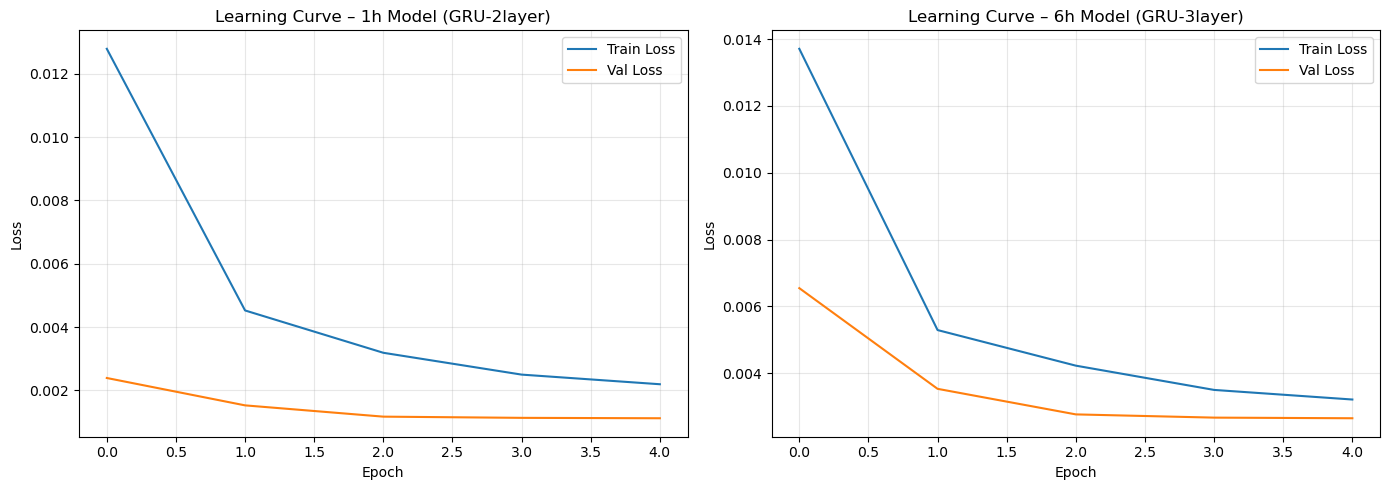

In [59]:
# Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1h model
axes[0].plot(history_1h.history['loss'], label='Train Loss')
axes[0].plot(history_1h.history['val_loss'], label='Val Loss')
axes[0].set_title('Learning Curve – 1h Model (GRU-2layer)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 6h model
axes[1].plot(history_6h.history['loss'], label='Train Loss')
axes[1].plot(history_6h.history['val_loss'], label='Val Loss')
axes[1].set_title('Learning Curve – 6h Model (GRU-3layer)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
from scipy.stats import wilcoxon

# Absolute percentage errors per sample
ape_1h = np.abs((y_true_1h - y_pred_1h) / y_true_1h) * 100
ape_6h = np.abs((y_true_6h - y_pred_6h) / y_true_6h) * 100

# Samain panjangnya kalau beda
min_len = min(len(ape_1h), len(ape_6h))
ape_1h = ape_1h[:min_len]
ape_6h = ape_6h[:min_len]

# Wilcoxon test
stat, p_value = wilcoxon(ape_1h, ape_6h)

print("=" * 50)
print("Wilcoxon Signed-Rank Test: 1h vs 6h")
print("=" * 50)
print(f"  Test statistic : {stat.item():.4f}")
print(f"  p-value        : {p_value.item():.6f}")
print()
if p_value < 0.05:
    print("✅ Significant (p < 0.05)")
    print("   → Error 1h dan 6h berbeda secara statistik")
else:
    print("❌ Not significant (p ≥ 0.05)")
    print("   → Error 1h dan 6h tidak berbeda signifikan")

Wilcoxon Signed-Rank Test: 1h vs 6h
  Test statistic : 458322.0000
  p-value        : 0.000000

✅ Significant (p < 0.05)
   → Error 1h dan 6h berbeda secara statistik


In [63]:
print(results_1layer.columns.tolist())
print(results_1layer.head())

['fold', 'MAE', 'RMSE', 'MAPE', 'architecture']
   fold        MAE       RMSE      MAPE architecture
0     1  26.354588  34.762758  2.248870   GRU-1layer
1     2  55.365343  69.744488  4.683282   GRU-1layer
2     3  53.863186  66.310355  4.480604   GRU-1layer
3     4  51.129758  64.196594  4.034076   GRU-1layer


In [64]:
from scipy.stats import wilcoxon

# Horizon 1h
mape_1layer = results_1layer['MAPE'].values
mape_2layer = results_2layer['MAPE'].values
mape_3layer = results_3layer['MAPE'].values

print("=" * 50)
print("Wilcoxon Test - Architecture Comparison (1h)")
print("=" * 50)

stat, p = wilcoxon(mape_1layer, mape_2layer)
print(f"1layer vs 2layer | stat={stat:.4f} | p={p:.6f} | {'✅ Significant' if p < 0.05 else '❌ Not significant'}")

stat, p = wilcoxon(mape_1layer, mape_3layer)
print(f"1layer vs 3layer | stat={stat:.4f} | p={p:.6f} | {'✅ Significant' if p < 0.05 else '❌ Not significant'}")

stat, p = wilcoxon(mape_2layer, mape_3layer)
print(f"2layer vs 3layer | stat={stat:.4f} | p={p:.6f} | {'✅ Significant' if p < 0.05 else '❌ Not significant'}")

Wilcoxon Test - Architecture Comparison (1h)
1layer vs 2layer | stat=4.0000 | p=0.875000 | ❌ Not significant
1layer vs 3layer | stat=4.0000 | p=0.875000 | ❌ Not significant
2layer vs 3layer | stat=4.0000 | p=0.875000 | ❌ Not significant


In [65]:
# Horizon 6h
mape_1layer_6h = results_1layer_6h['MAPE'].values
mape_2layer_6h = results_2layer_6h['MAPE'].values
mape_3layer_6h = results_3layer_6h['MAPE'].values

print("=" * 50)
print("Wilcoxon Test - Architecture Comparison (6h)")
print("=" * 50)

stat, p = wilcoxon(mape_1layer_6h, mape_2layer_6h)
print(f"1layer vs 2layer | stat={stat:.4f} | p={p:.6f} | {'✅ Significant' if p < 0.05 else '❌ Not significant'}")

stat, p = wilcoxon(mape_1layer_6h, mape_3layer_6h)
print(f"1layer vs 3layer | stat={stat:.4f} | p={p:.6f} | {'✅ Significant' if p < 0.05 else '❌ Not significant'}")

stat, p = wilcoxon(mape_2layer_6h, mape_3layer_6h)
print(f"2layer vs 3layer | stat={stat:.4f} | p={p:.6f} | {'✅ Significant' if p < 0.05 else '❌ Not significant'}")

Wilcoxon Test - Architecture Comparison (6h)
1layer vs 2layer | stat=0.0000 | p=0.125000 | ❌ Not significant
1layer vs 3layer | stat=0.0000 | p=0.125000 | ❌ Not significant
2layer vs 3layer | stat=2.0000 | p=0.375000 | ❌ Not significant


In [67]:
from scipy.stats import norm
import numpy as np

def diebold_mariano(e1, e2, h=1):
    d = e1**2 - e2**2
    n = len(d)
    d_mean = np.mean(d)
    
    # Newey-West variance
    gamma0 = np.var(d, ddof=1)
    gammas = []
    for lag in range(1, h+1):
        cov = np.mean((d[lag:] - d_mean) * (d[:-lag] - d_mean))
        gammas.append(cov)
    var_d = (gamma0 + 2 * sum(gammas)) / n
    
    dm_stat = d_mean / np.sqrt(abs(var_d))
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

e_1h = y_true_1h - y_pred_1h
e_6h = y_true_6h - y_pred_6h

min_len = min(len(e_1h), len(e_6h))
e_1h = e_1h[:min_len]
e_6h = e_6h[:min_len]

dm_stat, p_value = diebold_mariano(e_1h, e_6h, h=1)

print("=" * 50)
print("Diebold-Mariano Test: 1h vs 6h")
print("=" * 50)
print(f"  DM statistic : {dm_stat:.4f}")
print(f"  p-value      : {p_value:.6f}")
print()
if p_value < 0.05:
    print("✅ Significant (p < 0.05)")
    print("   → Model 1h signifikan lebih baik dari 6h")
else:
    print("❌ Not significant (p ≥ 0.05)")

Diebold-Mariano Test: 1h vs 6h
  DM statistic : -13.1794
  p-value      : 0.000000

✅ Significant (p < 0.05)
   → Model 1h signifikan lebih baik dari 6h


In [73]:
#hyperparameter tuning

from tensorflow.keras.models import Model
import tensorflow as tf
import keras_tuner as kt
print(kt.__version__)

1.4.8


In [74]:
def build_model_tuner(hp):
    units_1 = hp.Choice('units_1', values=[32, 64, 128])
    units_2 = hp.Choice('units_2', values=[16, 32, 64])
    dropout_rate = hp.Choice('dropout', values=[0.1, 0.2, 0.3])
    learning_rate = hp.Choice('learning_rate', values=[0.001, 0.0005, 0.0001])
    n_layers = hp.Choice('n_layers', values=[1, 2, 3])
    
    inputs = Input(shape=(X_train_final.shape[1], X_train_final.shape[2]))
    x = GRU(units_1, return_sequences=(n_layers > 1))(inputs)
    x = Dropout(dropout_rate)(x)
    
    if n_layers >= 2:
        x = GRU(units_2, return_sequences=(n_layers > 2))(x)
        x = Dropout(dropout_rate)(x)
    
    if n_layers >= 3:
        x = GRU(units_2 // 2, return_sequences=False)(x)
        x = Dropout(dropout_rate)(x)
    
    outputs = Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

In [75]:
# Tuning - Horizon 1h
tuner_1h = kt.BayesianOptimization(
    build_model_tuner,
    objective='val_loss',
    max_trials=10,
    directory='tuner_results',
    project_name='gru_tuning_1h'
)

tuner_1h.search(
    X_train_final, y_train_final,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Trial 10 Complete [00h 00m 03s]
val_loss: 0.0013693288201466203

Best val_loss So Far: 0.0009622509242035449
Total elapsed time: 00h 00m 45s


In [76]:
# Lihat semua trials
tuner_1h.results_summary()

# Lihat best hyperparameters
best_hps = tuner_1h.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters:")
print(f"  units_1      : {best_hps.get('units_1')}")
print(f"  units_2      : {best_hps.get('units_2')}")
print(f"  dropout      : {best_hps.get('dropout')}")
print(f"  learning_rate: {best_hps.get('learning_rate')}")
print(f"  n_layers     : {best_hps.get('n_layers')}")

Results summary
Results in tuner_results/gru_tuning_1h
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 07 summary
Hyperparameters:
units_1: 128
units_2: 64
dropout: 0.2
learning_rate: 0.001
n_layers: 1
Score: 0.0009622509242035449

Trial 06 summary
Hyperparameters:
units_1: 32
units_2: 64
dropout: 0.1
learning_rate: 0.001
n_layers: 3
Score: 0.0010713451774790883

Trial 02 summary
Hyperparameters:
units_1: 64
units_2: 32
dropout: 0.1
learning_rate: 0.001
n_layers: 1
Score: 0.001079084468074143

Trial 01 summary
Hyperparameters:
units_1: 128
units_2: 32
dropout: 0.3
learning_rate: 0.0005
n_layers: 1
Score: 0.0011659208685159683

Trial 03 summary
Hyperparameters:
units_1: 32
units_2: 64
dropout: 0.2
learning_rate: 0.001
n_layers: 3
Score: 0.0012276620836928487

Trial 09 summary
Hyperparameters:
units_1: 32
units_2: 32
dropout: 0.2
learning_rate: 0.001
n_layers: 1
Score: 0.0013693288201466203

Trial 04 summary
Hyperparameters:
units_1: 64
units_2: 64
dropout: 0.2


In [77]:
# Tuning - Horizon 6h
tuner_6h = kt.BayesianOptimization(
    build_model_tuner,
    objective='val_loss',
    max_trials=10,
    directory='tuner_results',
    project_name='gru_tuning_6h'
)

tuner_6h.search(
    X_train_final, y_train_final_6h,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Trial 10 Complete [00h 00m 05s]
val_loss: 0.0072831055149436

Best val_loss So Far: 0.0028072665445506573
Total elapsed time: 00h 00m 42s


In [78]:
tuner_6h.results_summary()

best_hps_6h = tuner_6h.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters:")
print(f"  units_1      : {best_hps_6h.get('units_1')}")
print(f"  units_2      : {best_hps_6h.get('units_2')}")
print(f"  dropout      : {best_hps_6h.get('dropout')}")
print(f"  learning_rate: {best_hps_6h.get('learning_rate')}")
print(f"  n_layers     : {best_hps_6h.get('n_layers')}")

Results summary
Results in tuner_results/gru_tuning_6h
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 03 summary
Hyperparameters:
units_1: 32
units_2: 32
dropout: 0.1
learning_rate: 0.001
n_layers: 2
Score: 0.0028072665445506573

Trial 01 summary
Hyperparameters:
units_1: 32
units_2: 64
dropout: 0.1
learning_rate: 0.0005
n_layers: 2
Score: 0.003608297323808074

Trial 02 summary
Hyperparameters:
units_1: 32
units_2: 32
dropout: 0.2
learning_rate: 0.001
n_layers: 1
Score: 0.0042446451261639595

Trial 00 summary
Hyperparameters:
units_1: 32
units_2: 32
dropout: 0.2
learning_rate: 0.0005
n_layers: 2
Score: 0.004676737356930971

Trial 04 summary
Hyperparameters:
units_1: 64
units_2: 16
dropout: 0.3
learning_rate: 0.0005
n_layers: 3
Score: 0.005393424071371555

Trial 08 summary
Hyperparameters:
units_1: 32
units_2: 32
dropout: 0.2
learning_rate: 0.0005
n_layers: 1
Score: 0.0058798883110284805

Trial 05 summary
Hyperparameters:
units_1: 128
units_2: 64
dropout: 0.2


In [79]:
# Retrain Final Model 1h dengan best hyperparameters
best_model_1h = tuner_1h.hypermodel.build(best_hps)

history_1h_tuned = best_model_1h.fit(
    X_train_final, y_train_final,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 0.0049 - mae: 0.0528 - val_loss: 0.0013 - val_mae: 0.0284 - learning_rate: 0.0010
Epoch 2/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 854us/step - loss: 0.0022 - mae: 0.0364 - val_loss: 0.0012 - val_mae: 0.0269 - learning_rate: 0.0010
Epoch 3/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step - loss: 0.0017 - mae: 0.0322 - val_loss: 9.6609e-04 - val_mae: 0.0239 - learning_rate: 0.0010
Epoch 4/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step - loss: 0.0015 - mae: 0.0299 - val_loss: 0.0011 - val_mae: 0.0264 - learning_rate: 5.0000e-04
Epoch 5/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step - loss: 0.0014 - mae: 0.0291 - val_loss: 8.8921e-04 - val_mae: 0.0223 - learning_rate: 5.0000e-04


In [80]:
# Retrain Final Model 6h dengan best hyperparameters
best_model_6h = tuner_6h.hypermodel.build(best_hps_6h)

history_6h_tuned = best_model_6h.fit(
    X_train_final, y_train_final_6h,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 792us/step - loss: 0.0159 - mae: 0.0930 - val_loss: 0.0068 - val_mae: 0.0669 - learning_rate: 0.0010
Epoch 2/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - loss: 0.0052 - mae: 0.0565 - val_loss: 0.0047 - val_mae: 0.0556 - learning_rate: 0.0010
Epoch 3/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - loss: 0.0040 - mae: 0.0493 - val_loss: 0.0027 - val_mae: 0.0407 - learning_rate: 0.0010
Epoch 4/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - loss: 0.0035 - mae: 0.0461 - val_loss: 0.0032 - val_mae: 0.0449 - learning_rate: 5.0000e-04
Epoch 5/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step - loss: 0.0033 - mae: 0.0444 - val_loss: 0.0025 - val_mae: 0.0395 - learning_rate: 5.0000e-04


In [81]:
# Evaluate tuned model 1h
y_pred_1h_tuned_scaled = best_model_1h.predict(X_test_final, verbose=0).flatten()
y_pred_1h_tuned = scaler_y_final.inverse_transform(y_pred_1h_tuned_scaled.reshape(-1, 1)).flatten()

mae_1h_tuned = mean_absolute_error(y_true_1h, y_pred_1h_tuned)
rmse_1h_tuned = np.sqrt(mean_squared_error(y_true_1h, y_pred_1h_tuned))
mape_1h_tuned = np.mean(np.abs((y_true_1h - y_pred_1h_tuned) / y_true_1h)) * 100

print("Tuned Model - Horizon 1h:")
print(f"  MAE  : {mae_1h_tuned:.2f} MWh")
print(f"  RMSE : {rmse_1h_tuned:.2f} MWh")
print(f"  MAPE : {mape_1h_tuned:.2f}%")
print(f"  vs sebelumnya: 4.36%")

# Evaluate tuned model 6h
y_pred_6h_tuned_scaled = best_model_6h.predict(X_test_final, verbose=0).flatten()
y_pred_6h_tuned = scaler_y_final.inverse_transform(y_pred_6h_tuned_scaled.reshape(-1, 1)).flatten()

mae_6h_tuned = mean_absolute_error(y_true_6h, y_pred_6h_tuned)
rmse_6h_tuned = np.sqrt(mean_squared_error(y_true_6h, y_pred_6h_tuned))
mape_6h_tuned = np.mean(np.abs((y_true_6h - y_pred_6h_tuned) / y_true_6h)) * 100

print("\nTuned Model - Horizon 6h:")
print(f"  MAE  : {mae_6h_tuned:.2f} MWh")
print(f"  RMSE : {rmse_6h_tuned:.2f} MWh")
print(f"  MAPE : {mape_6h_tuned:.2f}%")
print(f"  vs sebelumnya: 7.47%")

Tuned Model - Horizon 1h:
  MAE  : 37.41 MWh
  RMSE : 48.07 MWh
  MAPE : 17.03%
  vs sebelumnya: 4.36%

Tuned Model - Horizon 6h:
  MAE  : 92.35 MWh
  RMSE : 114.12 MWh
  MAPE : 16.62%
  vs sebelumnya: 7.47%


In [82]:
# Cek dengan scaler yang bener
y_pred_1h_tuned_scaled = best_model_1h.predict(X_test_final, verbose=0).flatten()

dummy_pred = np.zeros((len(y_pred_1h_tuned_scaled), len(feature_cols)))
dummy_pred[:, 0] = y_pred_1h_tuned_scaled

y_pred_1h_tuned = scaler_X_final.inverse_transform(dummy_pred)[:, 0]

mape_check = np.mean(np.abs((y_true_1h - y_pred_1h_tuned) / y_true_1h)) * 100
print(f"MAPE 1h tuned: {mape_check:.2f}%")

MAPE 1h tuned: 17.03%


In [83]:
print(X_test_final.shape)
print(y_true_1h.shape)
print(y_pred_1h_tuned_scaled.shape)
print(y_pred_1h_tuned_scaled[:5])
print(y_true_1h[:5])

(2184, 1, 33)
(2184, 1)
(2184,)
[0.3510883  0.3471197  0.34477127 0.3515395  0.3554093 ]
[[1017.5806]
 [1000.2797]
 [ 987.2383]
 [ 970.3667]
 [ 957.6767]]


In [84]:
# Flatten y_true dulu
y_true_1h_flat = y_true_1h.flatten()

# Inverse transform prediksi dengan scaler yang bener
y_pred_1h_tuned = scaler_y_final.inverse_transform(
    y_pred_1h_tuned_scaled.reshape(-1, 1)
).flatten()

mape_check = np.mean(np.abs((y_true_1h_flat - y_pred_1h_tuned) / y_true_1h_flat)) * 100
print(f"MAPE 1h tuned: {mape_check:.2f}%")
print(f"y_pred sample: {y_pred_1h_tuned[:5]}")

MAPE 1h tuned: 3.09%
y_pred sample: [968.2494  963.6426  960.9165  968.7732  973.26526]


In [85]:
y_true_6h_flat = y_true_6h.flatten()

y_pred_6h_tuned = scaler_y_final.inverse_transform(
    y_pred_6h_tuned_scaled.reshape(-1, 1)
).flatten()

mape_6h_check = np.mean(np.abs((y_true_6h_flat - y_pred_6h_tuned) / y_true_6h_flat)) * 100
print(f"MAPE 6h tuned: {mape_6h_check:.2f}%")
print(f"y_pred sample: {y_pred_6h_tuned[:5]}")

MAPE 6h tuned: 7.30%
y_pred sample: [ 935.84705  977.7627  1028.4246  1084.1589  1137.892  ]


# Sliding & Expanding

In [ ]:
# # Sliding window - 12h horizon
# results_sliding_12h = run_cv(splits, 'target_12h', 'Sliding Window')

In [ ]:
# # Expanding window - 12h horizon
# results_expanding_12h = run_cv(splits_expanding, 'target_12h', 'Expanding Window')

In [ ]:
# # Sliding window - 24h horizon
# results_sliding_24h = run_cv(splits, 'target_24h', 'Sliding Window')

In [ ]:
# # Expanding window - 24h horizon
# results_expanding_24h = run_cv(splits_expanding, 'target_24h', 'Expanding Window')

In [ ]:
# result comparison

# Add labels
results_sliding_12h['horizon'] = '12h'
results_sliding_12h['cv'] = 'Sliding'
results_expanding_12h['horizon'] = '12h'
results_expanding_12h['cv'] = 'Expanding'
results_sliding_24h['horizon'] = '24h'
results_sliding_24h['cv'] = 'Sliding'
results_expanding_24h['horizon'] = '24h'
results_expanding_24h['cv'] = 'Expanding'

# Combine
all_results = pd.concat([results_sliding_12h, results_expanding_12h,
                         results_sliding_24h, results_expanding_24h])

# Summary: mean per group
summary = all_results.groupby(['horizon', 'cv'])[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print(summary)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 5, figsize=(24, 8))
configs = [
    (splits, 'target_12h', 'Sliding Window - 12h'),
    (splits, 'target_24h', 'Sliding Window - 24h'),
]

for row, (split_list, target_col, title) in enumerate(configs):
    for col, (train_start, train_end, val_start, val_end) in enumerate(split_list):
        ax = axes[row, col]
        
        train = df_fe.loc[train_start:train_end]['nat_demand'].resample('D').mean()
        val_true = df_fe.loc[val_start:val_end][target_col].resample('D').mean()
        
        ax.plot(train.index, train.values, color='steelblue', linewidth=0.8)
        ax.plot(val_true.index, val_true.values, color='red', linewidth=0.8)
        ax.set_title(f'{title}\nFold {col+1}', fontsize=8)
        ax.tick_params(axis='x', rotation=45, labelsize=6)
        ax.tick_params(axis='y', labelsize=6)

blue_patch = mpatches.Patch(color='steelblue', label='Training')
red_patch = mpatches.Patch(color='red', label='Validation')
fig.legend(handles=[blue_patch, red_patch], loc='upper right', fontsize=10)
plt.suptitle('Sliding Window CV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Engineering (window sequence)

In [ ]:
# Feature Engineering for Sequence Window approach
df_seq = df_clean.copy()

# Temporal features
df_seq['hour'] = df_seq.index.hour
df_seq['dayofweek'] = df_seq.index.dayofweek
df_seq['month'] = df_seq.index.month
df_seq['is_weekend'] = (df_seq.index.dayofweek >= 5).astype(int)

# Cyclical encoding
df_seq['hour_sin'] = np.sin(2 * np.pi * df_seq['hour'] / 24)
df_seq['hour_cos'] = np.cos(2 * np.pi * df_seq['hour'] / 24)
df_seq['dow_sin'] = np.sin(2 * np.pi * df_seq['dayofweek'] / 7)
df_seq['dow_cos'] = np.cos(2 * np.pi * df_seq['dayofweek'] / 7)
df_seq['month_sin'] = np.sin(2 * np.pi * df_seq['month'] / 12)
df_seq['month_cos'] = np.cos(2 * np.pi * df_seq['month'] / 12)

print(df_seq.shape)
df_seq.head()

In [ ]:
df_seq.info()

In [ ]:
def create_sequences(df, feature_cols, target_col, window_size, gap=72, horizon=12):
    X, y, timestamps = [], [], []
    
    data = df[feature_cols].values
    target = df[target_col].values
    
    for i in range(window_size, len(data) - gap - horizon + 1):
        # Window: i-window_size sampai i (data historis)
        X.append(data[i - window_size:i])
        # Target: i + gap + horizon - 1 (gap 72 jam + horizon ke depan)
        y.append(target[i + gap + horizon - 1])
        timestamps.append(df.index[i + gap + horizon - 1])
    
    return np.array(X), np.array(y), timestamps

print("create_sequences function defined!")

In [ ]:
feature_cols = [
    'nat_demand',
    'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',
    'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san',
    'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'holiday', 'school', 'is_weekend'
]

print(f"Total features: {len(feature_cols)}")

In [ ]:
splits_sliding = [
    ('2015-01', '2015-12', '2016-01', '2016-06'),
    ('2016-01', '2016-12', '2017-01', '2017-06'),
    ('2017-01', '2017-12', '2018-01', '2018-06'),
    ('2018-01', '2018-12', '2019-01', '2019-06'),
    ('2019-01', '2019-12', '2020-01', '2020-06'),
]

splits_expanding = [
    ('2015-01', '2015-12', '2016-01', '2016-06'),
    ('2015-01', '2016-12', '2017-01', '2017-06'),
    ('2015-01', '2017-12', '2018-01', '2018-06'),
    ('2015-01', '2018-12', '2019-01', '2019-06'),
    ('2015-01', '2019-12', '2020-01', '2020-06'),
]

print("Splits defined!")

In [ ]:
#slice data fold-1

train_df = df_seq.loc['2015-01':'2015-12']
val_df = df_seq.loc['2016-01':'2016-06']

print(f"Train shape: {train_df.shape}")
print(f"Val shape: {val_df.shape}")

In [ ]:
#slice data fold-2

train_df = df_seq.loc['2016-01':'2016-12']
val_df = df_seq.loc['2017-01':'2017-06']

print(f"Train shape: {train_df.shape}")
print(f"Val shape: {val_df.shape}")

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_scaled = train_df.copy()
val_scaled = val_df.copy()

train_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_scaled[feature_cols] = scaler.transform(val_df[feature_cols])

print("Normalization done!")
print(train_scaled[feature_cols].min().min(), train_scaled[feature_cols].max().max())

In [ ]:
#create sequence

X_train, y_train, ts_train = create_sequences(
    train_scaled, feature_cols, 'nat_demand', 
    window_size=24, gap=72, horizon=12)

X_val, y_val, ts_val = create_sequences(
    val_scaled, feature_cols, 'nat_demand', 
    window_size=24, gap=72, horizon=12)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

In [ ]:
# build and train GRU

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout

def build_gru_model(input_shape):
    inputs = Input(shape=input_shape)
    x = GRU(64, return_sequences=True)(inputs)
    x = Dropout(0.2)(x)
    x = GRU(32, return_sequences=False)(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_gru_model((24, 22))
model.summary()

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

In [ ]:
#predict and evaluate

# Predict
y_pred_scaled = model.predict(X_val, verbose=0).flatten()

# Inverse transform
dummy_true = np.zeros((len(y_val), len(feature_cols)))
dummy_pred = np.zeros((len(y_val), len(feature_cols)))

dummy_true[:, 0] = y_val
dummy_pred[:, 0] = y_pred_scaled

y_true = scaler.inverse_transform(dummy_true)[:, 0]
y_pred = scaler.inverse_transform(dummy_pred)[:, 0]

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE:  {mae:.2f} MWh")
print(f"RMSE: {rmse:.2f} MWh")
print(f"MAPE: {mape:.2f}%")

In [ ]:
def run_fold(train_df, val_df, window_size, horizon):
    # Normalize
    scaler = MinMaxScaler()
    train_scaled = train_df.copy()
    val_scaled = val_df.copy()
    train_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    val_scaled[feature_cols] = scaler.transform(val_df[feature_cols])
    
    # Create sequences
    X_train, y_train, _ = create_sequences(train_scaled, feature_cols, 'nat_demand', window_size, gap=72, horizon=horizon)
    X_val, y_val, _ = create_sequences(val_scaled, feature_cols, 'nat_demand', window_size, gap=72, horizon=horizon)
    
    # Train
    model = build_gru_model((window_size, len(feature_cols)))
    model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0)
    
    # Predict & evaluate
    y_pred_scaled = model.predict(X_val, verbose=0).flatten()
    dummy_true = np.zeros((len(y_val), len(feature_cols)))
    dummy_pred = np.zeros((len(y_val), len(feature_cols)))
    dummy_true[:, 0] = y_val
    dummy_pred[:, 0] = y_pred_scaled
    y_true = scaler.inverse_transform(dummy_true)[:, 0]
    y_pred = scaler.inverse_transform(dummy_pred)[:, 0]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return mae, rmse, mape

print("run_fold function defined!")

In [ ]:
configs = [
    ('Sliding', splits_sliding, 24, 12),
    ('Sliding', splits_sliding, 24, 24),
    ('Sliding', splits_sliding, 48, 12),
    ('Sliding', splits_sliding, 48, 24),
    ('Expanding', splits_expanding, 24, 12),
    ('Expanding', splits_expanding, 24, 24),
    ('Expanding', splits_expanding, 48, 12),
    ('Expanding', splits_expanding, 48, 24),
]

all_results = []

for cv_name, splits, window_size, horizon in configs:
    print(f"\n{'='*60}")
    print(f"{cv_name} | window={window_size} | horizon={horizon}h")
    print(f"{'='*60}")
    
    for i, (train_start, train_end, val_start, val_end) in enumerate(splits):
        train_df = df_seq.loc[train_start:train_end]
        val_df = df_seq.loc[val_start:val_end]
        
        mae, rmse, mape = run_fold(train_df, val_df, window_size, horizon)
        print(f"Fold {i+1} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")
        
        all_results.append({
            'cv': cv_name, 'window': window_size, 
            'horizon': horizon, 'fold': i+1,
            'MAE': mae, 'RMSE': rmse, 'MAPE': mape
        })

results_df = pd.DataFrame(all_results)
print("\nDone!")

In [ ]:
summary = results_df.groupby(['cv', 'window', 'horizon'])[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print(summary)

In [ ]:
sliding_summary = results_df[results_df['cv'] == 'Sliding'].groupby(['window', 'horizon'])[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print("Sliding Window CV - Summary")
print("="*45)
print(sliding_summary.to_string())

In [ ]:
expanding_summary = results_df[results_df['cv'] == 'Expanding'].groupby(['window', 'horizon'])[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print("Expanding Window CV - Summary")
print("="*45)
print(expanding_summary.to_string())

In [ ]:
import keras_tuner as kt
print(keras_tuner.__version__)

In [ ]:
def build_model_tuner(hp):
    units_1 = hp.Choice('units_1', values=[32, 64, 128])
    units_2 = hp.Choice('units_2', values=[16, 32, 64])
    dropout_rate = hp.Choice('dropout', values=[0.1, 0.2, 0.3])
    learning_rate = hp.Choice('learning_rate', values=[0.001, 0.0005, 0.0001])
    
    inputs = Input(shape=(48, len(feature_cols)))
    x = GRU(units_1, return_sequences=True)(inputs)
    x = Dropout(dropout_rate)(x)
    x = GRU(units_2, return_sequences=False)(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1)(x)
    
    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

print("Tuner model function defined!")

In [ ]:
# Prepare data training biasa
train_df = df_seq.loc['2015-01':'2018-12']
val_df = df_seq.loc['2019-01':'2019-12']

scaler = MinMaxScaler()
train_scaled = train_df.copy()
val_scaled = val_df.copy()
train_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_scaled[feature_cols] = scaler.transform(val_df[feature_cols])

X_train, y_train, _ = create_sequences(train_scaled, feature_cols, 'nat_demand', window_size=48, gap=72, horizon=24)
X_val, y_val, _ = create_sequences(val_scaled, feature_cols, 'nat_demand', window_size=48, gap=72, horizon=24)

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")

In [ ]:
# Baseline model - default hyperparameters
baseline_model = build_gru_model((48, len(feature_cols)))

history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

In [ ]:
# Evaluate baseline
y_pred_baseline_scaled = baseline_model.predict(X_val, verbose=0).flatten()

dummy_true = np.zeros((len(y_val), len(feature_cols)))
dummy_pred = np.zeros((len(y_val), len(feature_cols)))
dummy_true[:, 0] = y_val
dummy_pred[:, 0] = y_pred_baseline_scaled

y_true = scaler.inverse_transform(dummy_true)[:, 0]
y_pred_baseline = scaler.inverse_transform(dummy_pred)[:, 0]

mae_baseline = mean_absolute_error(y_true, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred_baseline))
mape_baseline = np.mean(np.abs((y_true - y_pred_baseline) / y_true)) * 100

print("Baseline Model Performance:")
print(f"MAE:  {mae_baseline:.2f} MWh")
print(f"RMSE: {rmse_baseline:.2f} MWh")
print(f"MAPE: {mape_baseline:.2f}%")

In [ ]:
tuner = kt.BayesianOptimization(
    build_model_tuner,
    objective='val_loss',
    max_trials=10,
    directory='tuner_results',
    project_name='gru_tuning'
)

tuner.search(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

In [ ]:
best_hps = tuner.get_best_hyperparameters(1)[0]
print("Best Hyperparameters:")
print(f"  units_1:       {best_hps.get('units_1')}")
print(f"  units_2:       {best_hps.get('units_2')}")
print(f"  dropout:       {best_hps.get('dropout')}")
print(f"  learning_rate: {best_hps.get('learning_rate')}")

In [ ]:
tuned_model = tuner.hypermodel.build(best_hps)

history_tuned = tuned_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)